<a href="https://colab.research.google.com/github/Dyuko/DataScience/blob/main/pipeline_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets
!pip install evaluate
!pip install transformers

# Parte 1: Preprocesamiento

In [2]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from datasets import load_dataset, Dataset, Features, ClassLabel, Sequence, Value, DatasetDict

In [4]:
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
import numpy as np

## 1.1. Lee el archivo del conjunto de datos

In [6]:
# Lectura del archivo donde se encuentran los datos de entrenamiento y validación

data = pd.read_csv('/content/drive/MyDrive/datos/corpusTASS-2020/train.tsv', sep='\t')
data_dev = pd.read_csv('/content/drive/MyDrive/datos/corpusTASS-2020/dev.tsv', sep='\t')

In [7]:
data.head()

,id,texto,etiqueta,pais
0,768512386269638656,@morbosaborealis jajajaja... eso es verdad... ...,N,es
1,768529956162924544,@Adriansoler espero y deseo que el interior te...,NEU,es
2,768557093955698688,"comprendo que te molen mis tattoos, pero no te...",NEU,es
3,770616744192929792,"Mi última partida jugada, con Sona support. La...",P,es
4,769959690092642304,Tranquilos que con el.dinero de Camacho seguro...,P,es


## 1.2. Extrae los tweets y sus etiquetas de sentimiento y guardalos en una estructura dataset

In [8]:
data = data.drop(columns=['id', 'pais'])
data_dev = data_dev.drop(columns=['id', 'pais'])

In [9]:
# Diccionario de mapeo de etiquetas
mapeo_etiquetas = {'N': 0, 'NEU': 1, 'P': 2}

In [10]:
#definimos la estructura del dataset de Huggingface, la etiqueta es de tipo ClassLabel
# y la variable names contiene el nombre de las etiquetas en el mismo orden que el mapeo
features = Features({
    'texto': Value('string'),
    'etiqueta': ClassLabel(num_classes=3, names=['N', 'NEU','P'])
})

#transformamos de dataframe a dataset
dataset_train = Dataset.from_pandas(data, features=features)
dataset_dev = Dataset.from_pandas(data_dev, features=features)

dataset_train = dataset_train.rename_column("texto", "text")
dataset_train = dataset_train.rename_column("etiqueta", "label")
dataset_dev = dataset_dev.rename_column("texto", "text")
dataset_dev = dataset_dev.rename_column("etiqueta", "label")

In [11]:
dataset_train[0]

{'text': '@morbosaborealis jajajaja... eso es verdad... aquí no hay uno cuerdo ',
 'label': 0}

In [12]:
#creamos diccionario de dataset
datasetTass = DatasetDict({'train': dataset_train, 'test': dataset_dev})
datasetTass

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 4802
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2443
    })
})

## 1.3. (Opcional) Haz una limpieza ligera del texto (eliminación de URLs, menciones, etc.)

In [13]:
# Define a function for light text cleaning
def clean_text(text):
    """
    Perform light cleaning on text:
    - Remove URLs
    - Remove mentions (@username)
    - Remove hashtags (#hashtag)
    - Remove extra whitespaces
    - Convert to lowercase
    """
    import re

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags
    text = re.sub(r'#(\w+)', r'\1', text)

    # Remove special characters and numbers
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text)

    # Convert to lowercase
    text = text.lower().strip()

    return text

In [14]:
# Apply the cleaning function to both datasets
datasetTass = datasetTass.map(lambda example: {'text': clean_text(example['text'])})

Map:   0%|          | 0/4802 [00:00<?, ? examples/s]

Map:   0%|          | 0/2443 [00:00<?, ? examples/s]

In [15]:
# Check a few examples to see the cleaning results
print("Original vs Cleaned examples:")
for i in range(3):
    original_text = dataset_train['text'][i]
    cleaned_text = datasetTass['train']['text'][i]
    print(f"Original: {original_text}")
    print(f"Cleaned: {cleaned_text}")
    print("-" * 50)

Original vs Cleaned examples:
Original: @morbosaborealis jajajaja... eso es verdad... aquí no hay uno cuerdo 
Cleaned: jajajaja eso es verdad aquí no hay uno cuerdo
--------------------------------------------------
Original: @Adriansoler espero y deseo que el interior te cause lo mismo 
Cleaned: espero y deseo que el interior te cause lo mismo
--------------------------------------------------
Original: comprendo que te molen mis tattoos, pero no te los hagas 'iguales' 
Cleaned: comprendo que te molen mis tattoos pero no te los hagas iguales
--------------------------------------------------


# Parte 2: Análisis con modelos preentrenados

## 2.1. Usa un modelo en español compatible con análisis de sentimiento desde Hugging Face

In [16]:
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset

In [17]:
# KeyDataset is a utility that returns the item in the dict returned by the dataset
# Initialize the pipeline with the multilingual sentiment model
pipe = pipeline(task="text-classification", model="nlptown/bert-base-multilingual-uncased-sentiment")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Device set to use cuda:0


## 2.2 Aplica el modelo a los textos del corpus para predecir el sentimiento.

In [18]:
# Perform prediction on the test dataset and store the result
resultado = list(pipe(KeyDataset(datasetTass['test'], "text"), batch_size=8, truncation="only_first"))

In [19]:
textos = datasetTass['test']['text']
etiquetas = datasetTass['test']['label']

In [20]:
print(len(textos), len(etiquetas), len(resultado))

2443 2443 2443


In [21]:
resultado_df = pd.DataFrame({
    'Texto': textos,
    'Etiqueta': etiquetas,
    'Prediccion': [r['label'] for r in resultado],
    'Confianza': [r['score'] for r in resultado]
})

In [22]:
# Mostramos el resultado en un dataframe
resultado_df

,Texto,Etiqueta,Prediccion,Confianza
0,no seas muy dura,0,3 stars,0.292660
1,podemos usar el términoequipo pepino,1,1 star,0.246042
2,como destrozaba el puto movil ahora mismo,0,1 star,0.606759
3,me ofrecería pero gerald es demasiado lindo,1,3 stars,0.498336
4,no creo que hayan diseñado una tipo propia,0,2 stars,0.378243
...,...,...,...,...
2438,no todo es tan malo,1,1 star,0.550814
2439,a ver ya no seas así,0,5 stars,0.328318
2440,ocupo el gym en serio videomtv abraham mateo,1,1 star,0.234530
2441,empezar de nuevo con la dieta es tan difícil,0,2 stars,0.367178


In [38]:
# Since the multilingual model uses star ratings (1-5), we need to map these to our classes
# Let's create a mapping from stars to our sentiment classes
def map_stars_to_sentiment(star_rating):
    star_num = int(star_rating.split()[0])
    if star_num <= 1:
        return 0  # Negative
    elif star_num <= 3:
        return 1  # Neutral
    else:
        return 2  # Positive

In [39]:
# Apply the mapping to convert star ratings to sentiment classes
resultado_df['Prediccion_Num'] = resultado_df['Prediccion'].apply(map_stars_to_sentiment)

In [40]:
resultado_df

,Texto,Etiqueta,Prediccion,Confianza,Prediccion_Num,Etiqueta_Texto,Prediccion_Texto,Correcto
0,no seas muy dura,0,3 stars,0.292660,1,NEG,NEG,True
1,podemos usar el términoequipo pepino,1,1 star,0.246042,0,NEU,NEG,False
2,como destrozaba el puto movil ahora mismo,0,1 star,0.606759,0,NEG,NEG,True
3,me ofrecería pero gerald es demasiado lindo,1,3 stars,0.498336,1,NEU,NEG,False
4,no creo que hayan diseñado una tipo propia,0,2 stars,0.378243,1,NEG,NEG,True
...,...,...,...,...,...,...,...,...
2438,no todo es tan malo,1,1 star,0.550814,0,NEU,NEG,False
2439,a ver ya no seas así,0,5 stars,0.328318,2,NEG,POS,False
2440,ocupo el gym en serio videomtv abraham mateo,1,1 star,0.234530,0,NEU,NEG,False
2441,empezar de nuevo con la dieta es tan difícil,0,2 stars,0.367178,1,NEG,NEG,True


## 2.3. Compara los resultados del modelo con las etiquetas reales.

In [41]:
# Calculate evaluation metrics
y_true = resultado_df['Etiqueta'].astype(int)
y_pred = resultado_df['Prediccion_Num'].astype(int)

In [42]:
# Add columns with human-readable labels for better visualization
label_map = {0: 'NEG', 1: 'NEU', 2: 'POS'}
resultado_df['Etiqueta_Texto'] = resultado_df['Etiqueta'].map(label_map)
resultado_df['Prediccion_Texto'] = resultado_df['Prediccion_Num'].map(label_map)

# Calculate if prediction was correct
resultado_df['Correcto'] = (resultado_df['Etiqueta'] == resultado_df['Prediccion_Num'])

# Display side by side comparison
print("Side by side comparison of predictions vs real labels:")
comparison_df = resultado_df[['Texto', 'Etiqueta_Texto', 'Prediccion_Texto', 'Prediccion', 'Correcto', 'Confianza']]
comparison_df = comparison_df.rename(columns={
    'Texto': 'Text',
    'Etiqueta_Texto': 'Real Label',
    'Prediccion_Texto': 'Predicted Label',
    'Prediccion': 'Star Rating',
    'Correcto': 'Correct?',
    'Confianza': 'Confidence'
})

# Show first 20 examples
comparison_df.head(20)

Side by side comparison of predictions vs real labels:


,Text,Real Label,Predicted Label,Star Rating,Correct?,Confidence
0,no seas muy dura,NEG,NEU,3 stars,False,0.292660
1,podemos usar el términoequipo pepino,NEU,NEG,1 star,False,0.246042
2,como destrozaba el puto movil ahora mismo,NEG,NEG,1 star,True,0.606759
3,me ofrecería pero gerald es demasiado lindo,NEU,NEU,3 stars,True,0.498336
4,no creo que hayan diseñado una tipo propia,NEG,NEU,2 stars,False,0.378243
5,yo no tengo tiempo para esas cosas ahora mismo,NEG,NEG,1 star,True,0.336282
6,nfin no puede ser peor que un minikayato clauy...,NEG,NEG,1 star,True,0.417472
7,mañana sábado en que día vives mañana es miérc...,NEU,POS,5 stars,False,0.306960
8,las tengo pero aún no las he leído caerán pron...,POS,NEU,2 stars,False,0.357551
9,ves ese brillo es un coso que hace que se sepa...,NEG,POS,5 stars,False,0.227011


## 2.4. Calcula métricas como accuracy, F1-score, precision, recall

In [43]:
# Calculate classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NEG', 'NEU', 'POS']))


Classification Report:
              precision    recall  f1-score   support

         NEG       0.57      0.55      0.56       951
         NEU       0.41      0.31      0.35       793
         POS       0.51      0.67      0.58       699

    accuracy                           0.51      2443
   macro avg       0.50      0.51      0.50      2443
weighted avg       0.50      0.51      0.50      2443



# 3. Parte 3: Análisis cualitativo

## 3.1. Muestra ejemplos donde el modelo acierta y donde falla.

In [48]:
# Mostrar ejemplos correctos con alta confianza (ejemplos positivos)
correct_high_confidence = resultado_df[resultado_df['Correcto'] & (resultado_df['Confianza'] > 0.9)].sample(5)
print("Ejemplos correctos con alta confianza:")
display(correct_high_confidence[['Texto', 'Etiqueta', 'Prediccion_Num', 'Confianza']])

Ejemplos correctos con alta confianza:


,Texto,Etiqueta,Prediccion_Num,Confianza
1505,horrible cantan estas chicas,0,0,0.942013
1122,igual muchos lugares aun perdira el x pagan co...,0,0,0.914239
2018,la peor noticia nos quedamos sin americano en ...,0,0,0.928011
2395,una verdadera estupidez vamos a ver juegazos c...,0,0,0.953363
2382,este es un asalto tome mi cartera jaja inocent...,0,0,0.912167


In [49]:
# Mostrar ejemplos correctos difíciles (baja confianza pero correctos)
correct_low_confidence = resultado_df[resultado_df['Correcto'] & (resultado_df['Confianza'] < 0.6)].sample(5)
print("\nEjemplos correctos con baja confianza (clasificaciones difíciles):")
display(correct_low_confidence[['Texto', 'Etiqueta', 'Prediccion_Num', 'Confianza']])


Ejemplos correctos con baja confianza (clasificaciones difíciles):


,Texto,Etiqueta,Prediccion_Num,Confianza
1234,eso ya es una opinión fundamentada,2,2,0.323517
1055,me gusta estar sola y me molesta la gente que ...,1,1,0.375913
849,en comentarios que linda graciaaas te extraño ...,2,2,0.304473
443,me ha explotado un vaso en la mano que forma t...,0,0,0.482555
802,qué triste debe ser redactar una nota bien ale...,0,0,0.404741


In [50]:
# Mostrar errores con alta confianza (los más problemáticos)
wrong_high_confidence = resultado_df[~resultado_df['Correcto'] & (resultado_df['Confianza'] > 0.8)].sample(5)
print("\nErrores con alta confianza (falsos positivos/negativos):")
display(wrong_high_confidence[['Texto', 'Etiqueta', 'Prediccion_Num', 'Confianza']])


Errores con alta confianza (falsos positivos/negativos):


,Texto,Etiqueta,Prediccion_Num,Confianza
1715,es asesinado el embajador ruso en turquía y ah...,1,0,0.816810
56,y lo peor de todo es que funcionaba maldita ja...,1,0,0.806388
2046,genial espero que algun dia sacan uno de bleac...,1,2,0.822621
1571,son las grandes promesas nuestras,1,2,0.856182
1059,feliz año bella las mejores vibras,1,2,0.838654


In [51]:
# Mostrar errores más comprensibles (baja confianza)
wrong_low_confidence = resultado_df[~resultado_df['Correcto'] & (resultado_df['Confianza'] < 0.6)].sample(5)
print("\nErrores con baja confianza (clasificaciones ambiguas):")
display(wrong_low_confidence[['Texto', 'Etiqueta', 'Prediccion_Num', 'Confianza']])


Errores con baja confianza (clasificaciones ambiguas):


,Texto,Etiqueta,Prediccion_Num,Confianza
1201,tazloco q en paz descanses gorda la mejor perr...,0,2,0.490860
27,es dirección de proyectos en empresas audiovis...,1,2,0.388539
2288,no eres la única,1,0,0.313472
1129,de nuevo abandone el tw,1,0,0.492797
1523,la carita feliz fue una advertencia se dan cue...,0,2,0.453695


## 3.2. Analiza si el modelo presenta sesgos, errores comunes o confusiones entre clases.

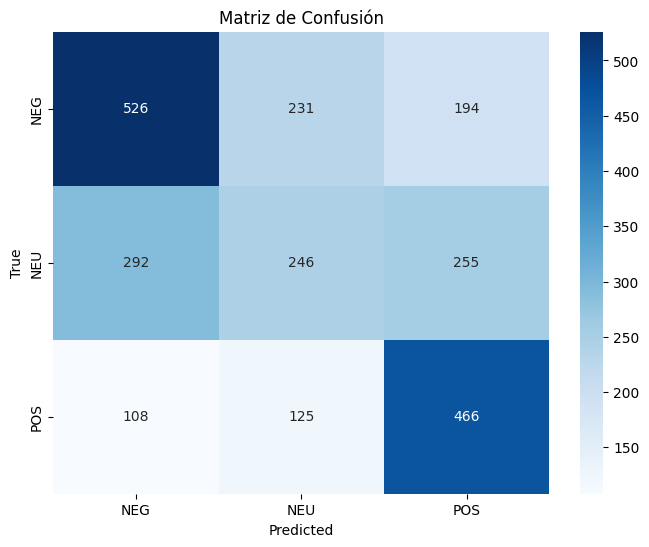

In [52]:
# Matriz de confusión para identificar patrones de error
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.values(),
            yticklabels=label_map.values())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de Confusión')
plt.show()

El modelo presenta confusión significativa entre las clases NEG y NEU

La clase NEU es la más ambigua, con errores repartidos hacia ambos extremos (NEG y POS)